<a href="https://colab.research.google.com/github/Maryam-Skaik/chicago-crime-time-series-analysis/blob/main/notebook/chicago_crime_time_series_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicago Crime Time Series Analysis

## Project 3 - Part 1

### Objective
This project analyzes crime trends in Chicago using historical crime records.

The goal is to answer stakeholder questions related to:

1. Police District Crime Comparison
2. Crime Trends Across Years
3. Crime Patterns During Holidays
4. Seasonal Cycles in Crime Data

The analysis uses Python, Pandas, Matplotlib, Seaborn, and Statsmodels.

## Import Libraries

In [76]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import holidays

from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

## Load Data

The crime dataset is distributed as separate yearly files.

This section loads all files and combines them into a single DataFrame.

In [77]:
import os
DATA_PATH = Path("/content/drive/MyDrive/AXSOSACADEMY/04-Time Series Analysis/Week13/Data/Chicago_Crime_2001-2022.zip")

print(os.path.exists(DATA_PATH))

True


In [78]:
import zipfile

zip_path = DATA_PATH

with zipfile.ZipFile(zip_path, 'r') as z:
    print(z.namelist())  # see files inside

['Data/Chicago-Crime_2001.csv', 'Data/Chicago-Crime_2002.csv', 'Data/Chicago-Crime_2003.csv', 'Data/Chicago-Crime_2004.csv', 'Data/Chicago-Crime_2005.csv', 'Data/Chicago-Crime_2006.csv', 'Data/Chicago-Crime_2007.csv', 'Data/Chicago-Crime_2008.csv', 'Data/Chicago-Crime_2009.csv', 'Data/Chicago-Crime_2010.csv', 'Data/Chicago-Crime_2011.csv', 'Data/Chicago-Crime_2012.csv', 'Data/Chicago-Crime_2013.csv', 'Data/Chicago-Crime_2014.csv', 'Data/Chicago-Crime_2015.csv', 'Data/Chicago-Crime_2016.csv', 'Data/Chicago-Crime_2017.csv', 'Data/Chicago-Crime_2018.csv', 'Data/Chicago-Crime_2019.csv', 'Data/Chicago-Crime_2020.csv', 'Data/Chicago-Crime_2021.csv', 'Data/Chicago-Crime_2022.csv', 'Data/README.txt']


In [79]:
import pandas as pd
import zipfile

dfs = []

with zipfile.ZipFile(zip_path, 'r') as z:
    for file in z.namelist():
        if file.endswith(".csv"):
            with z.open(file) as f:
                dfs.append(pd.read_csv(f))

print(len(dfs))

22


In [80]:
df = pd.concat(dfs, ignore_index=True)

print(df.shape)

df.head()

(7713109, 12)


,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,1326041,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185
1,1319931,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841
2,1324743,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970
3,1310717,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032
4,1318099,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020


**First Observation from the Dataset**

The dataset contains **7,713,109 rows and 12 columns**. The first records show crime incidents in Chicago starting from **01/01/2001**. Most early entries include offenses such as **BATTERY**, **GAMBLING**, and **CRIMINAL DAMAGE**, occurring in different locations like **RESIDENCE**, **STREET**, and **RESIDENCE PORCH/HALLWAY**.

Several fields provide structured details about each incident, including whether the case involved **arrest or domestic violence**, the **police beat and district**, and the **geographical coordinates (Latitude and Longitude)**. Some values, such as **Ward**, contain missing data in early records.

## Inspect Dataset

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7713109 entries, 0 to 7713108
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Date                  object 
 2   Primary Type          object 
 3   Description           object 
 4   Location Description  object 
 5   Arrest                bool   
 6   Domestic              bool   
 7   Beat                  int64  
 8   District              float64
 9   Ward                  float64
 10  Latitude              float64
 11  Longitude             float64
dtypes: bool(2), float64(4), int64(2), object(4)
memory usage: 603.2+ MB


**Dataset Structure Overview**

The dataset contains **7,713,109 records and 12 columns**. It includes a mix of data types: **4 object columns**, **2 integer columns**, **4 float columns**, and **2 boolean columns**.

Key fields include **Date** (stored as object type and needs conversion to datetime for time series analysis), categorical crime details such as **Primary Type**, **Description**, and **Location Description**, and boolean indicators for **Arrest** and **Domestic** cases.

Geographical and administrative information is represented through **Beat, District, Ward, Latitude, and Longitude**, where some fields (like Ward and coordinates) contain missing values.

In [82]:
df.describe(include='all').round(2)

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
count,7713109.00,7713109,7713109,7713109,7702181,7713109,7713109,7713109.00,7713062.00,7098263.00,7624424.00,7624424.00
unique,NaN,3172250,36,547,215,2,2,NaN,NaN,NaN,NaN,NaN
top,NaN,01/01/2008 12:01:00 AM,THEFT,SIMPLE,STREET,False,False,NaN,NaN,NaN,NaN,NaN
freq,NaN,304,1626992,905302,2005166,5686559,6389834,NaN,NaN,NaN,NaN,NaN
mean,6971245.08,NaN,NaN,NaN,NaN,NaN,NaN,1186.29,11.30,22.75,41.84,-87.67
std,3471022.39,NaN,NaN,NaN,NaN,NaN,NaN,703.06,6.95,13.85,0.09,0.06
min,634.00,NaN,NaN,NaN,NaN,NaN,NaN,111.00,1.00,1.00,36.62,-91.69
25%,3759720.00,NaN,NaN,NaN,NaN,NaN,NaN,621.00,6.00,10.00,41.77,-87.71
50%,6975839.00,NaN,NaN,NaN,NaN,NaN,NaN,1034.00,10.00,23.00,41.86,-87.67
75%,10038197.00,NaN,NaN,NaN,NaN,NaN,NaN,1731.00,17.00,34.00,41.91,-87.63


**Dataset Summary Statistics**

* The dataset contains **7,713,109 total records** across all columns, with some missing values in fields like **Location Description, District, Ward, Latitude, and Longitude**.

* **Date column**
  * Spans **3,172,250 unique timestamps**
  * Most frequent timestamp: **01/01/2008 12:01:00 AM (304 occurrences)**

* **Crime categories**
  * **36 unique Primary Types**, with **THEFT** being the most common (1,626,992 occurrences)
  * **547 unique Descriptions**, with **SIMPLE** as the most frequent (905,302 occurrences)

* **Location data**
  * **215 unique Location Descriptions**
  * Most common location: **STREET (2,005,166 cases)**

* **Arrest & Domestic cases**
  * Most cases are **non-arrests (5,686,559)**
  * Majority are **non-domestic incidents (6,389,834)**

* **Geographical and administrative fields**
  * **Beat** ranges from 111 to 2,535 (mean: 1,186)
  * **District** ranges from 1 to 31 (mean: 11.3)
  * **Ward** ranges from 1 to 50 (mean: 22.75)
  * **Latitude** ranges from 36.62 to 42.02 (centered around ~41.84)
  * **Longitude** ranges from -91.69 to -87.52 (centered around ~-87.67)

* **Overall pattern**
  * Crime data is heavily concentrated in a small number of categories (especially theft and simple assaults)
  * Most incidents are non-arrest and non-domestic
  * Spatial data is consistent with Chicago area coordinates, with some outliers in latitude/longitude values

In [83]:
df.isna().sum().sort_values(ascending=False)

,0
Ward,614846
Latitude,88685
Longitude,88685
Location Description,10928
District,47
Primary Type,0
Date,0
ID,0
Description,0
Beat,0


#### Missing Values Handling Strategy

* **Ward (614,846 missing)**
  * High missing rate → avoid statistical imputation.
  * Best approach: fill with **placeholder (-1 or "Unknown")** or derive from **Beat/District mapping if available**.

* **Latitude & Longitude (88,685 missing each)**
  * Time-series + spatial nature → use **interpolation**.

* **Location Description (10,928 missing)**
  * Categorical feature → fill with **"UNKNOWN LOCATION"** placeholder.

* **District (47 missing)**
  * Very small proportion → use **forward fill (ffill)** or **backward fill (bfill)** after sorting by Date.

* **All other columns (Primary Type, Date, ID, Description, Beat, Arrest, Domestic)**
  * No missing values → no imputation required.

In [84]:
df = df.drop(columns=['ID'])
df.head()

,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185
1,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841
2,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970
3,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032
4,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020


## Datetime Preparation

In [85]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df = df.set_index("Date")

df.head()

,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
Date,,,,,,,,,,
2001-01-01,THEFT,FINANCIAL ID THEFT: OVER $300,STREET,False,False,2221,22.0,21.0,41.732563,-87.669923
2001-01-01,THEFT,AGG: FINANCIAL ID THEFT,RESIDENCE,False,False,812,8.0,NaN,41.778094,-87.770137
2001-01-01,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,RESIDENCE,False,False,2124,2.0,4.0,41.807275,-87.593707
2001-01-01,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,915,9.0,20.0,41.806311,-87.674782
2001-01-01,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,CHURCH/SYNAGOGUE/PLACE OF WORSHIP,False,False,1022,10.0,24.0,NaN,NaN


In [86]:
print("Start Date:", df.index.min())
print("End Date:", df.index.max())

Start Date: 2001-01-01 00:00:00
End Date: 2022-12-31 23:55:00


* The **Date column** was converted to `datetime`, sorted, and set as the **index**, enabling time series analysis.

* After preprocessing, the dataset is structured chronologically from:
  * **Start:** 2001-01-01
  * **End:** 2022-12-31

* This transformation allows:
  * Efficient **time-based grouping and resampling**
  * Easier handling of **trends, seasonality, and missing time intervals**
  * Proper foundation for **time series modeling and analysis**

## Create Daily Crime Series

In [87]:
daily_crime = df.resample("D").size()

daily_crime = daily_crime.to_frame("Total_Crimes")

daily_crime.head()

,Total_Crimes
Date,
2001-01-01,1825
2001-01-02,1143
2001-01-03,1151
2001-01-04,1166
2001-01-05,1267


Each row currently represents a single crime.

For time series analysis we create a daily crime count dataset.

## Feature Engineering - Holidays

In [88]:
us_holidays = holidays.US()

daily_crime["Holiday"] = daily_crime.index.map(
    lambda x: us_holidays.get(x)
)

daily_crime.head()

,Total_Crimes,Holiday
Date,,
2001-01-01,1825,New Year's Day
2001-01-02,1143,None
2001-01-03,1151,None
2001-01-04,1166,None
2001-01-05,1267,None


This section adds United States holidays to the dataset.

## Topic 1: Police District Comparison

### Stakeholder Question

- Which district had the most crimes in 2022?

- Which district had the least crimes in 2022?

In [89]:
crime_2022 = df[df.index.year == 2022]

district_counts = (
    crime_2022["District"]
    .value_counts()
    .sort_values(ascending=False)
)

district_counts.head()

,count
District,
8.0,14805
6.0,14694
12.0,14341
4.0,13931
11.0,13457


In [90]:
district_counts.tail()

,count
District,
14.0,8158
22.0,7671
17.0,6997
20.0,4960
31.0,15


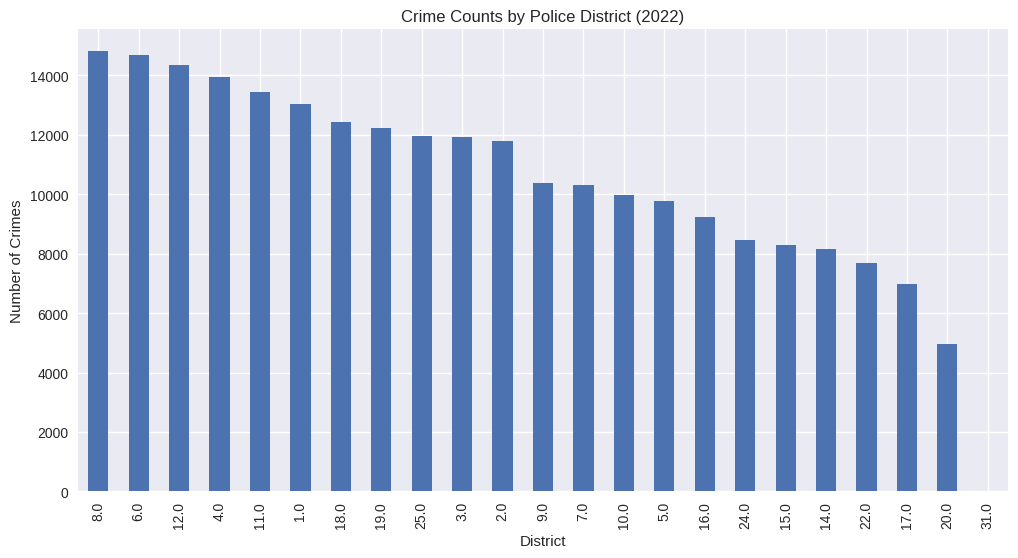

In [91]:
plt.figure(figsize=(12,6))

district_counts.plot(kind="bar")

plt.title("Crime Counts by Police District (2022)")
plt.ylabel("Number of Crimes")
plt.xlabel("District")

plt.show();

#### Crimes by District (2022)

* Filtered the dataset to include only crimes that occurred in **2022**.
* Counted the number of crimes per **police district** using `value_counts()`.

##### Most crimes in 2022

* **District 8** recorded the highest number of crimes (**14,805 incidents**)

##### Least crimes in 2022

* **District 31** recorded the lowest number of crimes (**15 incidents**)

* The bar chart clearly shows a strong imbalance in crime distribution across districts.

## Topic 2: Crime Trends Across Years

### Stakeholder Questions

- Is crime increasing or decreasing over time?
- Are there crimes that behave differently from the overall trend?

In [92]:
yearly_crimes = df.resample("YE").size()

yearly_crimes

,0
Date,
2001-12-31,485886
2002-12-31,486807
2003-12-31,475985
2004-12-31,469422
2005-12-31,453773
2006-12-31,448179
2007-12-31,437087
2008-12-31,427183
2009-12-31,392827


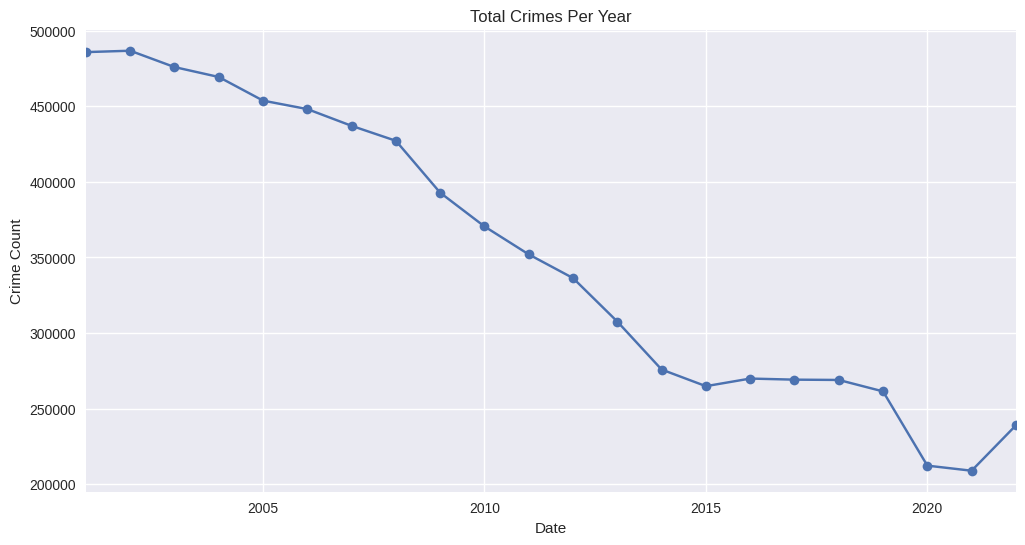

In [93]:
plt.figure(figsize=(12,6))

yearly_crimes.plot(marker="o")

plt.title("Total Crimes Per Year")
plt.ylabel("Crime Count")

plt.show()

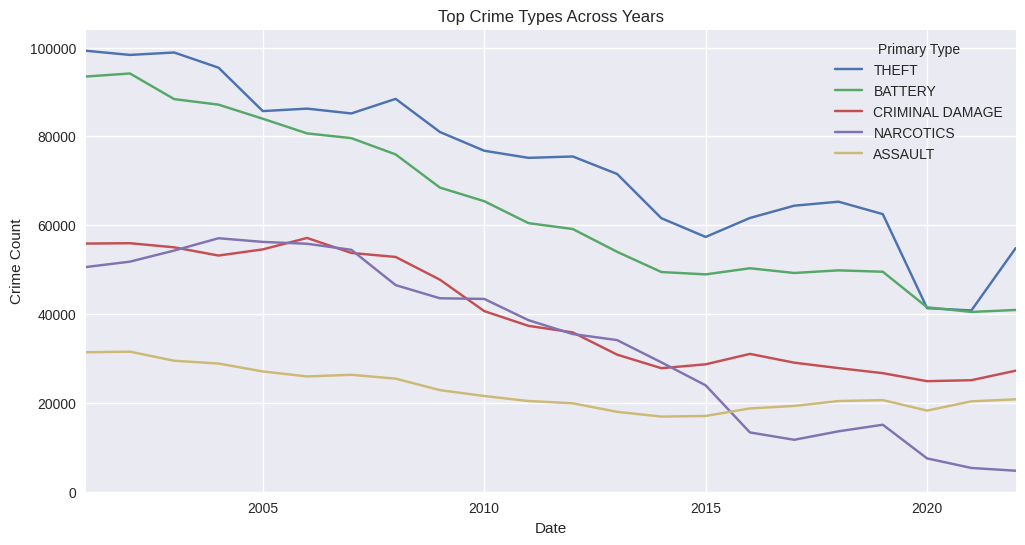

In [94]:
top_crimes = df["Primary Type"].value_counts().head(5).index

crime_by_year = (
    df.groupby([
        pd.Grouper(freq="YE"),
        "Primary Type"
    ])
    .size()
    .unstack(fill_value=0)
)

crime_by_year[top_crimes].plot(
    figsize=(12,6)
)

plt.title("Top Crime Types Across Years")
plt.ylabel("Crime Count")

plt.show();

In [95]:
crime_by_year

Primary Type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,DOMESTIC VIOLENCE,GAMBLING,HOMICIDE,HUMAN TRAFFICKING,INTERFERENCE WITH PUBLIC OFFICER,INTIMIDATION,KIDNAPPING,LIQUOR LAW VIOLATION,MOTOR VEHICLE THEFT,NARCOTICS,NON - CRIMINAL,NON-CRIMINAL,NON-CRIMINAL (SUBJECT SPECIFIED),OBSCENITY,OFFENSE INVOLVING CHILDREN,OTHER NARCOTIC VIOLATION,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,RITUALISM,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2001-12-31,1011,31384,93461,26014,1,1779,55859,29,13241,14949,1,934,667,0,406,279,933,1637,27553,50567,0,0,0,19,2263,6,29662,6026,9,2750,8,18441,2239,204,99277,4277
2002-12-31,1032,31523,94153,25623,0,1807,55941,27,13880,13732,0,971,658,0,361,337,829,1414,25121,51789,0,0,0,26,2594,5,32600,6408,8,2457,2,18523,2173,200,98332,4281
2003-12-31,955,29477,88380,25157,0,1571,55011,41,14807,13459,0,1088,604,0,409,364,705,1311,22748,54288,0,1,0,16,3047,2,31148,6214,6,2430,2,17332,2078,247,98876,4211
2004-12-31,778,28850,87136,24564,0,1538,53164,42,15913,13255,0,1122,455,0,531,349,482,985,22805,57060,0,0,0,13,3099,9,29532,7476,9,2495,1,15978,1805,215,95463,4298
2005-12-31,691,27067,83964,25503,0,1521,54548,37,16655,13590,0,1078,453,0,615,258,389,1005,22497,56234,0,0,0,19,2906,9,28028,6124,4,2730,2,16047,1817,192,85684,4106
2006-12-31,726,25945,80666,24324,0,1439,57124,47,14505,13606,0,1368,476,0,758,276,339,1135,21818,55813,0,0,0,17,2783,9,27101,7034,4,3068,7,15968,1576,186,86240,3821
2007-12-31,712,26313,79593,24858,0,1507,53749,53,13699,14170,0,1409,448,0,677,255,329,1170,18573,54454,0,0,0,12,2921,12,26863,6087,5,3315,1,15450,1529,213,85156,3554
2008-12-31,644,25448,75930,26218,0,1515,52843,47,12310,14933,0,1199,513,0,580,261,359,912,18881,46506,0,0,0,13,2661,12,26532,5141,4,3013,0,16703,1501,190,88437,3877
2009-12-31,616,22861,68460,26767,0,1401,47725,42,10851,13877,0,991,461,0,573,231,293,746,15482,43542,0,1,0,21,2632,7,25601,3940,10,3147,0,15981,1265,168,80976,4159


#### Crime Trend Analysis (Time Series)

* The **total number of crimes per year** shows a clear **long-term decreasing trend**.
* Crime counts drop significantly from **2001 (~485K cases)** to around **2014–2021 (~260K–210K cases)**.
* A noticeable **decline after 2010** is consistent, with a sharp reduction around **2020–2021** (possible external influence like COVID-19).

##### Overall trend

* **Crime is decreasing over time**, despite small fluctuations in recent years.

#### Behavior of Different Crime Types

* Analysis of top crime categories shows that not all crimes follow the same pattern:

##### Decreasing trends

* **THEFT, BURGLARY, BATTERY, CRIMINAL DAMAGE** → strong long-term decline.

##### Stable or slightly increasing trends

* **ASSAULT and WEAPONS VIOLATION** → relatively stable with minor fluctuations.

##### Special behavior

* **MOTOR VEHICLE THEFT** shows a **recent increase after 2019–2022**.
* **HOMICIDE and ARSON** remain low but show irregular patterns (more volatile than other crimes).

#### Key Insight

* While overall crime is declining, **some specific crime types behave differently**, showing that the general downward trend does not apply uniformly across all categories.

## Topic 5: Holiday Analysis

### Stakeholder Questions

- Which holidays have the most crimes?
- What are the most common crimes during those holidays?

In [96]:
holiday_df = daily_crime.dropna(subset=["Holiday"])

holiday_totals = (
    holiday_df.groupby("Holiday")["Total_Crimes"]
    .sum()
    .sort_values(ascending=False)
)

holiday_totals.head(10)

,Total_Crimes
Holiday,
New Year's Day,32725
Independence Day,22672
Labor Day,22164
Memorial Day,21125
Columbus Day,20920
Veterans Day,20418
Martin Luther King Jr. Day,17916
Washington's Birthday,17597
Thanksgiving Day,14798


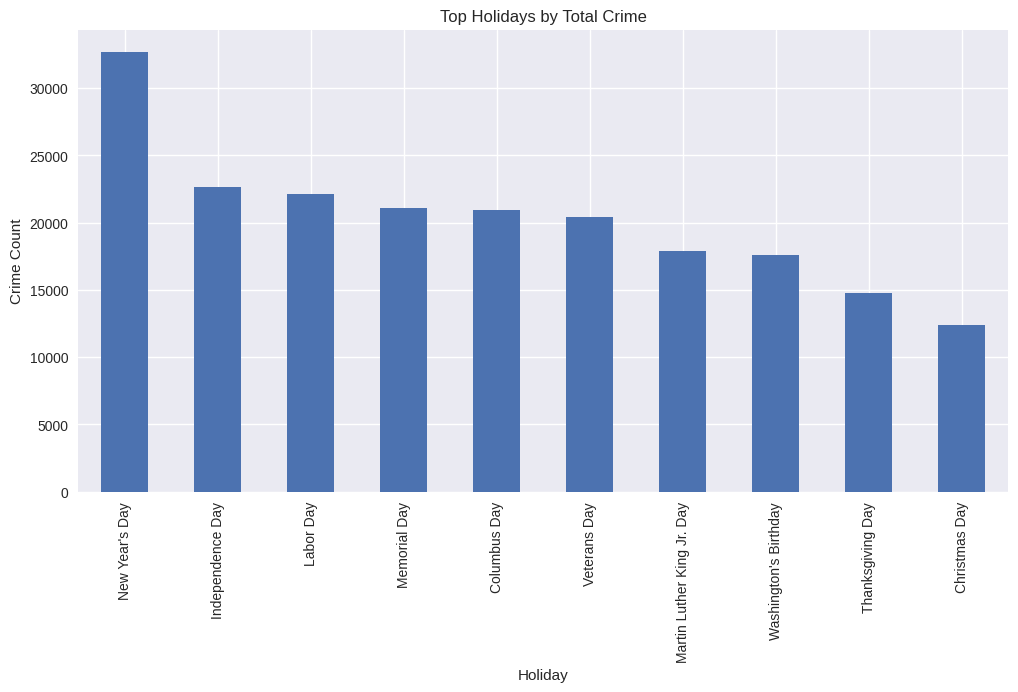

In [97]:
plt.figure(figsize=(12,6))

holiday_totals.head(10).plot(kind="bar")

plt.title("Top Holidays by Total Crime")
plt.ylabel("Crime Count")

plt.show();

In [98]:
top3_holidays = holiday_totals.head(3).index.tolist()

top3_holidays

["New Year's Day", 'Independence Day', 'Labor Day']

In [99]:
for holiday_name in top3_holidays:

    holiday_dates = [
        d for d, h in us_holidays.items()
        if h == holiday_name
    ]

    holiday_crimes = df[
        df.index.normalize().isin(
            pd.to_datetime(holiday_dates)
        )
    ]

    print("\n")
    print("="*60)
    print(holiday_name)

    display(
        holiday_crimes["Primary Type"]
        .value_counts()
        .head(5)
    )



New Year's Day


,count
Primary Type,
THEFT,6845
BATTERY,6043
CRIMINAL DAMAGE,3236
DECEPTIVE PRACTICE,2934
OFFENSE INVOLVING CHILDREN,2380




Independence Day


,count
Primary Type,
BATTERY,5805
THEFT,4074
CRIMINAL DAMAGE,3309
ASSAULT,1547
NARCOTICS,1522




Labor Day


,count
Primary Type,
BATTERY,4607
THEFT,4520
CRIMINAL DAMAGE,2475
NARCOTICS,2078
ASSAULT,1525


#### Crimes During Holidays

##### Holidays with the highest crime counts

* **New Year’s Day** → highest number of crimes (**32,725 total cases**)

* Followed by:
  * Independence Day (22,672)
  * Labor Day (22,164)
  * Memorial Day (21,125)
  * Columbus Day (20,920)

* These results show that **major public holidays tend to have increased crime activity**, likely due to gatherings and increased mobility.

#### Most common crimes during top holidays

##### New Year’s Day

* THEFT
* BATTERY
* CRIMINAL DAMAGE
* DECEPTIVE PRACTICE
* OFFENSE INVOLVING CHILDREN

##### Independence Day

* BATTERY
* THEFT
* CRIMINAL DAMAGE
* ASSAULT
* NARCOTICS

##### Labor Day

* BATTERY
* THEFT
* CRIMINAL DAMAGE
* NARCOTICS
* ASSAULT

#### Key Insight

* Across all major holidays, the **most frequent crimes are consistently violent or property-related**, especially:

  * BATTERY
  * THEFT
  * CRIMINAL DAMAGE
* This suggests that holidays amplify **both social interaction and risk of conflict or opportunistic crimes**.

## Topic 6: Time Series Seasonality

### Stakeholder Questions

- Are there repeating cycles?
- How long is each cycle?
- What is the magnitude of the cycle?

In [100]:
monthly_crime = daily_crime["Total_Crimes"].resample("MS").sum()

monthly_crime.head()

,Total_Crimes
Date,
2001-01-01,38119
2001-02-01,33787
2001-03-01,40566
2001-04-01,40091
2001-05-01,41839


In [101]:
decomposition = seasonal_decompose(
    monthly_crime,
    model="additive",
    period=12
)

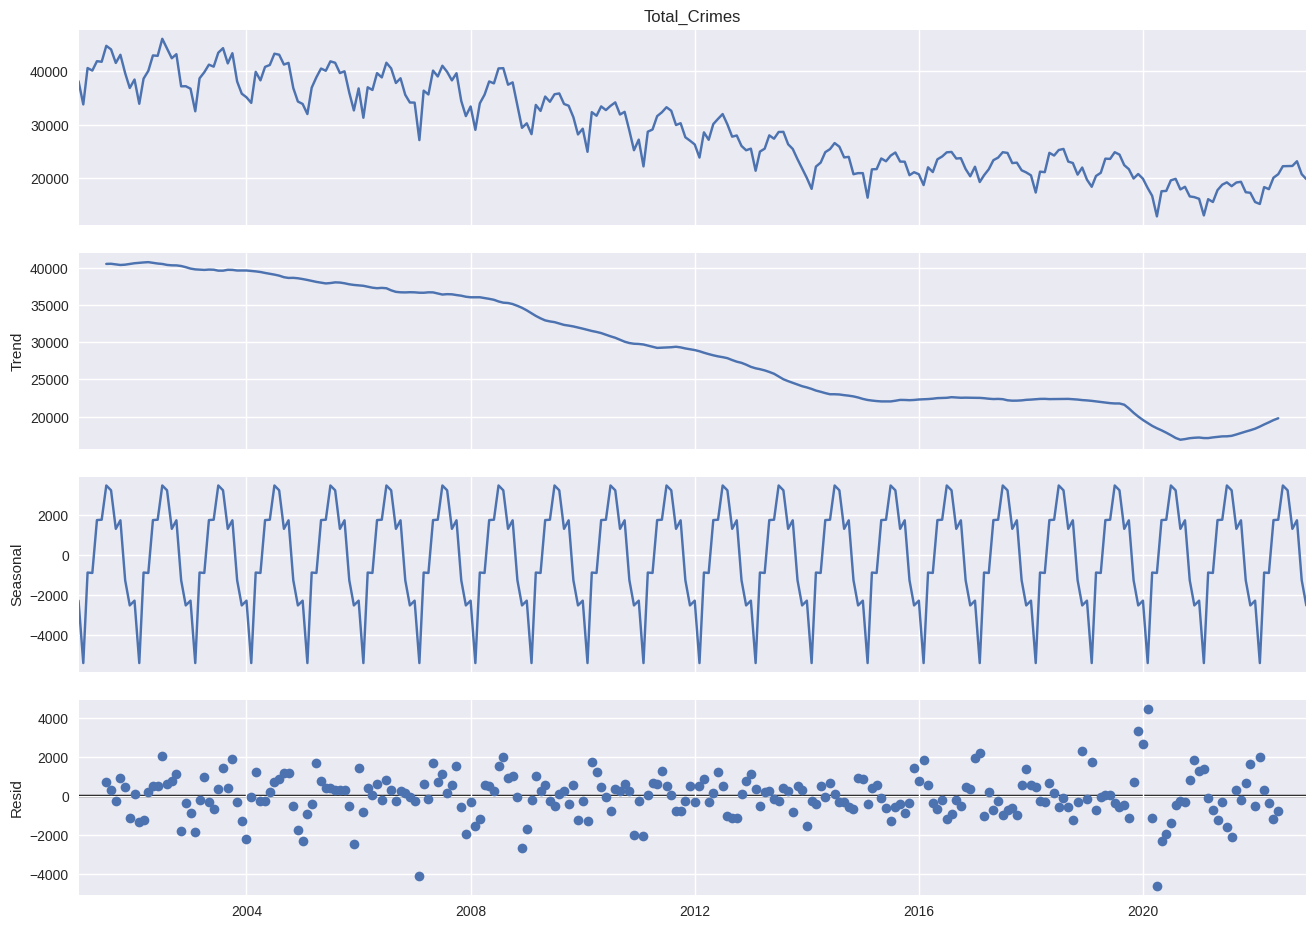

In [102]:
fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.show()

In [103]:
seasonal_component = decomposition.seasonal

seasonal_component.describe()

,seasonal
count,2.640000e+02
mean,-4.306320e-14
std,2.549043e+03
min,-5.416089e+03
25%,-1.521592e+03
50%,2.140146e+02
75%,1.752166e+03
max,3.481655e+03


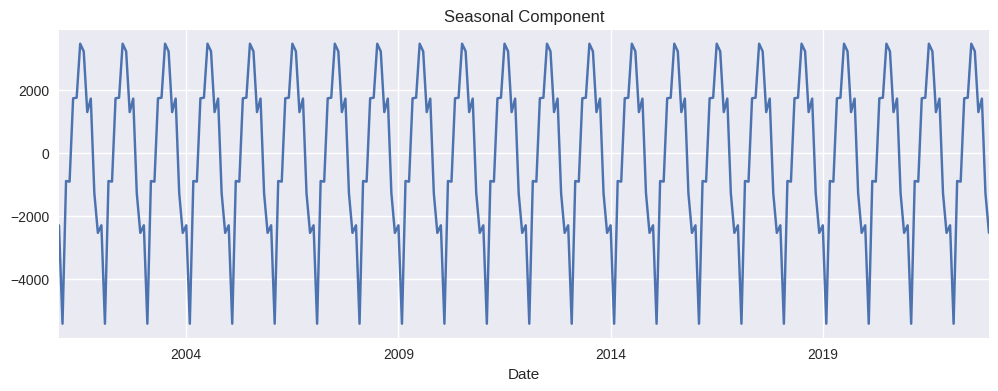

In [104]:
seasonal_component.plot(
    figsize=(12,4)
)

plt.title("Seasonal Component")

plt.show()

##### Cyclic Patterns in Crime Data

#### Are there repeating cycles?

* Yes, the decomposition shows a **clear seasonal pattern** in crime data.
* The **seasonal component repeats consistently over time**, indicating stable yearly behavior.

##### How long is each cycle?

* The cycle length used is **12 months** (`period = 12`).
* This confirms a **yearly seasonal cycle**, meaning crime patterns repeat on an **annual basis**.

##### What is the magnitude of the cycle?

* The seasonal effect ranges approximately from:

  * **Minimum:** ~ -5,400
  * **Maximum:** ~ +3,480
  * **Standard deviation:** ~ 2,550

* This shows that seasonal variation can shift monthly crime counts by **several thousand cases above or below the trend**, but remains smaller than the long-term trend component.

#### Key Insight

* Crime in this dataset is influenced by:

  * A **strong long-term downward trend**
  * A **stable yearly seasonal cycle**
* Seasonality exists but is **moderate compared to the overall trend**, meaning long-term changes dominate crime behavior more than repeating monthly patterns.

# Project 3 - Part 2: Crime Forecasting (ARIMA / SARIMA)
## Objective

In this phase, we forecast Chicago crime counts for the next 6 months using time series models.

We will compare two selected crime types and evaluate:

Manual ARIMA/SARIMA model
- Auto ARIMA model
- Forecast accuracy
- Future 6-month predictions
- Net and percent change

## Imports

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.tsa.api as tsa

from pmdarima import auto_arima

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, root_mean_squared_error

plt.style.use("seaborn-v0_8")

## Custom Functions

In [113]:
def prepare_monthly_series(df, crime_type=None):
    """
    Returns monthly time series for a given crime type or total crime.
    """
    if crime_type:
        temp = df[df["Primary Type"] == crime_type]
    else:
        temp = df.copy()

    ts = temp.resample("MS").size()
    ts = ts.to_frame("count")

    ts["count"] = ts["count"].ffill()

    return ts

In [106]:
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs):
    (test_stat, pval, nlags, nobs, crit_vals_d,
     icbest) = tsa.adfuller(ts, **kwargs)

    adfuller_results = {
        'Test Statistic': test_stat,
        "# of Lags Used": nlags,
        '# of Observations': nobs,
        'p-value': round(pval, 6),
        'alpha': alpha,
        'sig/stationary?': pval < alpha
    }

    return pd.DataFrame(adfuller_results, index=[label])

In [124]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10,4), title='Comparing Forecast vs. True Data'):

    fig, ax = plt.subplots(figsize=figsize)

    if n_train_lags is None:
        n_train_lags = len(ts_train)

    # Train + test
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(ax=ax, label="test")

    # Forecast mean
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")

    # Confidence interval (SAFE CHECK)
    if 'mean_ci_lower' in forecast_df.columns and 'mean_ci_upper' in forecast_df.columns:
        ax.fill_between(
            forecast_df.index,
            forecast_df['mean_ci_lower'],
            forecast_df['mean_ci_upper'],
            color='green',
            alpha=0.3
        )

    ax.set_title(title)
    ax.legend()

    return fig, ax

In [108]:
def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True, output_dict=False):

    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = root_mean_squared_error(ts_true, ts_pred)
    r_squared = r2_score(ts_true, ts_pred)
    mape = mean_absolute_percentage_error(ts_true, ts_pred) * 100

    if verbose:
        print("---" * 20)
        print(f"Regression Metrics: {label}")
        print("---" * 20)
        print(f"MAE = {mae:.3f}")
        print(f"MSE = {mse:.3f}")
        print(f"RMSE = {rmse:.3f}")
        print(f"R2 = {r_squared:.3f}")
        print(f"MAPE = {mape:.2f}%")

    if output_dict:
        return {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r_squared,
            "MAPE": mape
        }

In [109]:
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                  acf_kws={}, pacf_kws={},
                  annotate_seas=False, m=None,
                  seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)

    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)
    tsa.graphics.plot_pacf(ts, ax=axes[1], lags=nlags, **pacf_kws)

    fig.tight_layout()
    return fig

## Select Crimes for Forecasting

In [110]:
crime_types = ["THEFT", "BATTERY"]

## Build Monthly Time Series

In [111]:
theft_ts = prepare_monthly_series(df, "THEFT")
battery_ts = prepare_monthly_series(df, "BATTERY")

/tmp/ipykernel_580/175558814.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ts["count"] = ts["count"].fillna(method="ffill")
/tmp/ipykernel_580/175558814.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ts["count"] = ts["count"].fillna(method="ffill")


## Train-Test Split (6-month forecast)

In [112]:
def train_test_split_ts(ts, test_size=6):
    train = ts.iloc[:-test_size]
    test = ts.iloc[-test_size:]
    return train, test

theft_train, theft_test = train_test_split_ts(theft_ts)
battery_train, battery_test = train_test_split_ts(battery_ts)

## Stationarity Check (ADF Test)

In [115]:
get_adfuller_results(theft_train["count"], label="THEFT")

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
THEFT,-1.324272,13,244,0.617996,0.05,False


In [116]:
get_adfuller_results(battery_train["count"], label="BATTERY")

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
BATTERY,-1.102951,15,242,0.713894,0.05,False


## ACF / PACF Analysis

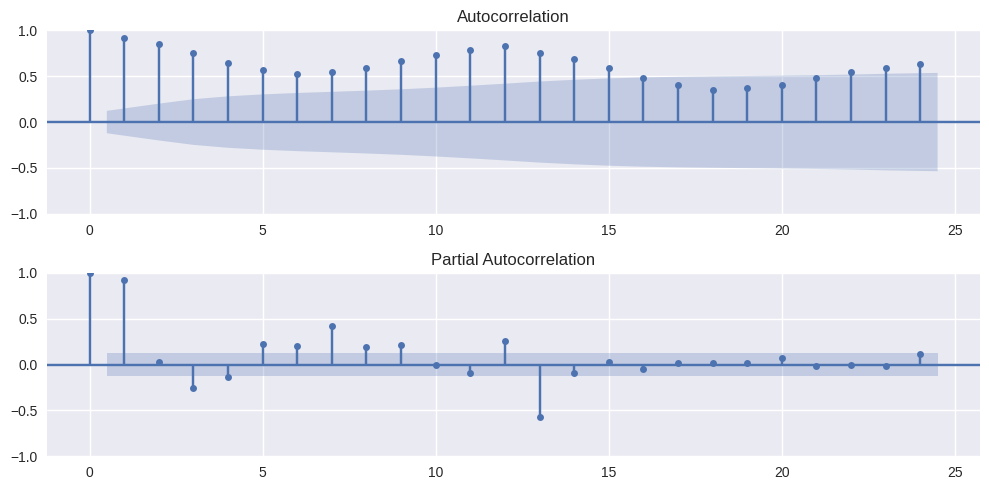

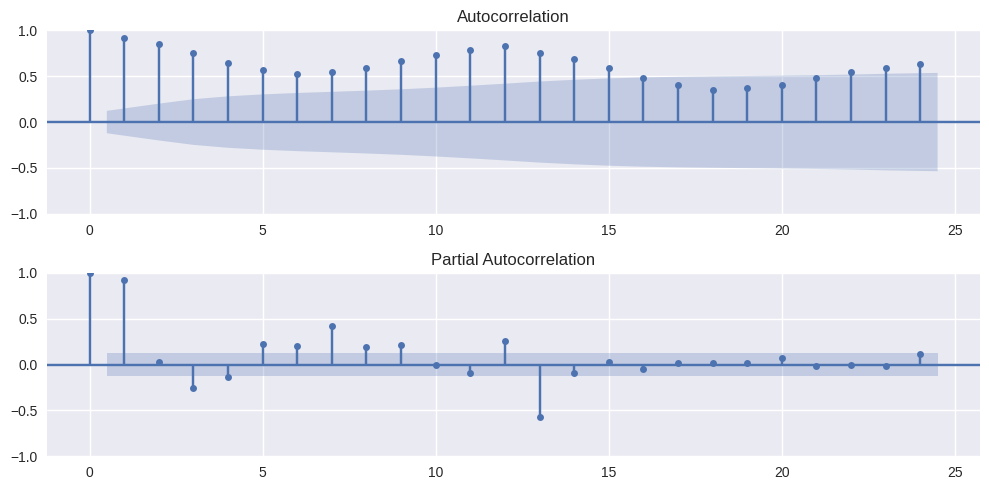

In [117]:
plot_acf_pacf(theft_train["count"], nlags=24)

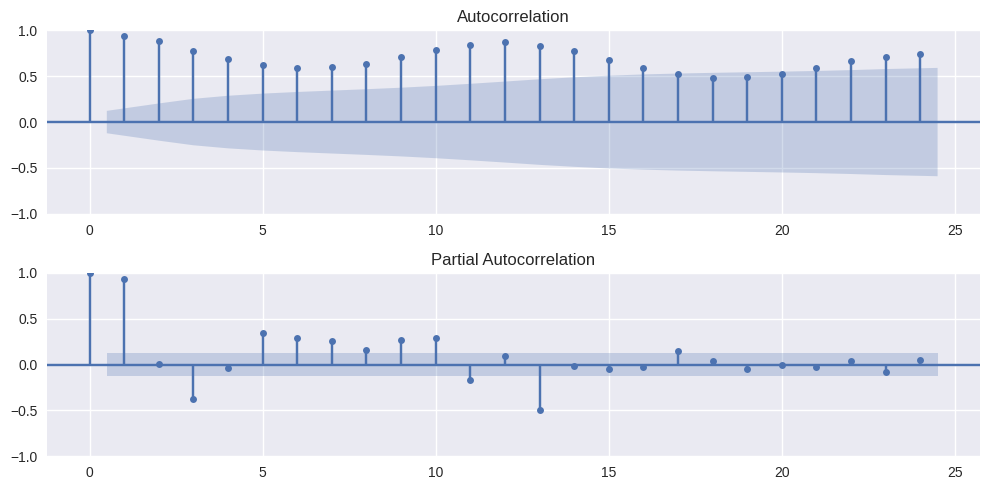

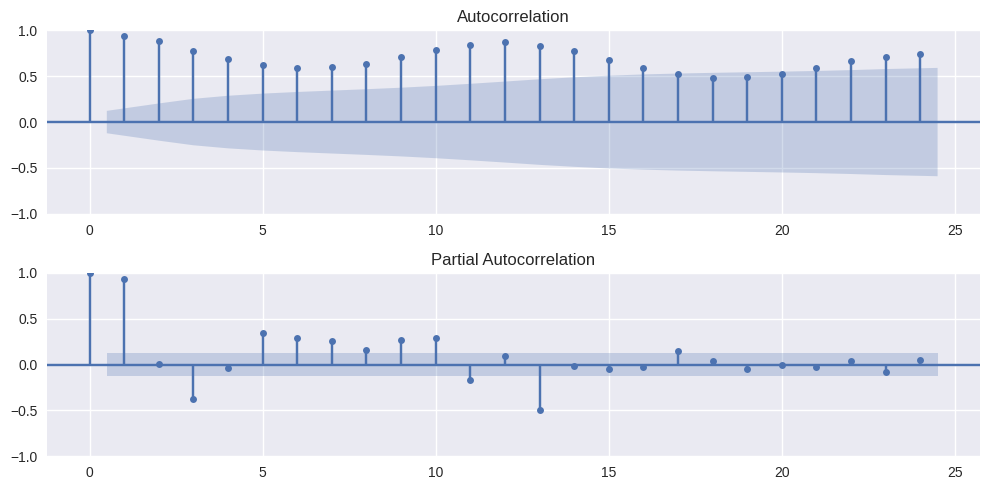

In [118]:
plot_acf_pacf(battery_train["count"], nlags=24)

## Manual ARIMA Model (THEFT)

In [119]:
from statsmodels.tsa.arima.model import ARIMA

theft_model = ARIMA(theft_train["count"], order=(1,1,1))
theft_result = theft_model.fit()

theft_forecast = theft_result.get_forecast(steps=6)
theft_forecast_df = theft_forecast.summary_frame()

## Evaluate Manual Model (THEFT)

------------------------------------------------------------
Regression Metrics: THEFT Manual ARIMA
------------------------------------------------------------
MAE = 360.614
MSE = 181248.761
RMSE = 425.733
R2 = -0.027
MAPE = 7.16%


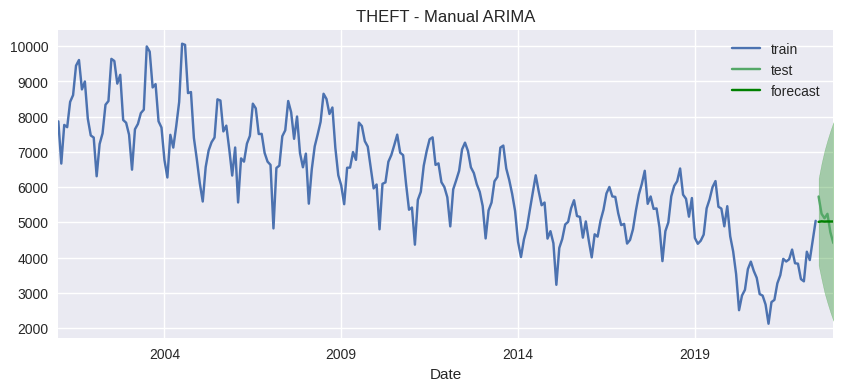

In [120]:
plot_forecast(theft_train["count"], theft_test["count"], theft_forecast_df,
              title="THEFT - Manual ARIMA")

regression_metrics_ts(
    theft_test["count"],
    theft_forecast_df["mean"],
    label="THEFT Manual ARIMA"
)

## Auto ARIMA (THEFT)

In [121]:
theft_auto = auto_arima(
    theft_train["count"],
    seasonal=True,
    m=12,
    trace=True,
    stepwise=True
)

theft_auto.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=5.00 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4050.524, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3791.710, Time=0.46 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3914.631, Time=0.46 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4048.603, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=4050.805, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=3774.214, Time=1.20 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=3743.851, Time=4.84 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=3743.960, Time=4.07 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=4.30 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=3742.901, Time=3.83 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=3870.719, Time=2.02 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=3913.736, Time=2.27 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=3754.859, Time=4.81 sec
 ARIMA(2,1,0)(1,0,2)[12] inte

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                       y   No. Observations:                  258
Model:             SARIMAX(1, 1, 0)x(1, 0, [1, 2], 12)   Log Likelihood               -1865.634
Date:                                 Sun, 21 Jun 2026   AIC                           3741.268
Time:                                         08:55:43   BIC                           3759.013
Sample:                                     01-01-2001   HQIC                          3748.404
                                          - 06-01-2022                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2251      0.046     -4.934      0.000      -0.315      -0.136
ar.S.L12       0.9778      0.008    120.055      0.000       0.962       0.994
ma.S.L12      -0.5771      0.059     -9.815      0.000      -0.692      -0.462
ma.S.L24      -0.1202      0.068     -1.758      0.079      -0.254       0.014
sigma2      1.038e+05   7353.336     14.120      0.000    8.94e+04    1.18e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                30.54
Prob(Q):                              0.87   Prob(JB):                         0.00
Heteroskedasticity (H):               0.80   Skew:                            -0.44
Prob(H) (two-sided):                  0.31   Kurtosis:                         4.44
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Auto ARIMA Forecast (THEFT)

In [122]:
theft_auto_pred = theft_auto.predict(n_periods=6)

theft_auto_df = pd.DataFrame({
    "mean": theft_auto_pred
}, index=theft_test.index)

## Evaluate Auto ARIMA (THEFT)

------------------------------------------------------------
Regression Metrics: THEFT Auto ARIMA
------------------------------------------------------------
MAE = 211.158
MSE = 72805.087
RMSE = 269.824
R2 = 0.587
MAPE = 4.27%


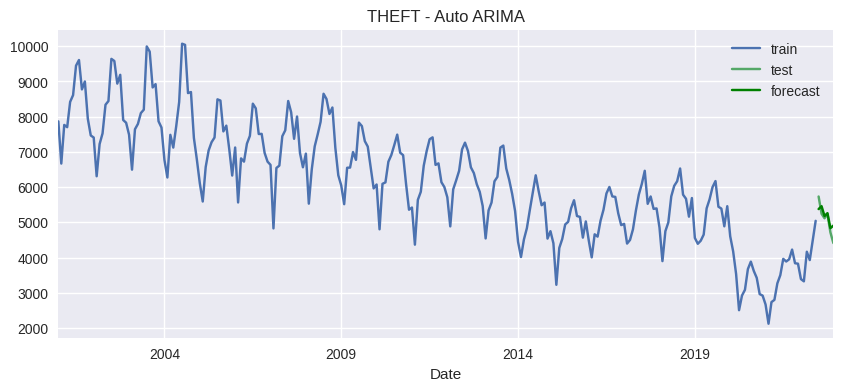

In [125]:
plot_forecast(theft_train["count"], theft_test["count"], theft_auto_df,
              title="THEFT - Auto ARIMA")

regression_metrics_ts(
    theft_test["count"],
    theft_auto_df["mean"],
    label="THEFT Auto ARIMA"
)

## Repeat for BATTERY

In [126]:
battery_model = ARIMA(battery_train["count"], order=(1,1,1))
battery_result = battery_model.fit()

battery_forecast = battery_result.get_forecast(steps=6)
battery_forecast_df = battery_forecast.summary_frame()

------------------------------------------------------------
Regression Metrics: BATTERY Manual ARIMA
------------------------------------------------------------
MAE = 414.375
MSE = 267134.658
RMSE = 516.851
R2 = -1.760
MAPE = 12.90%


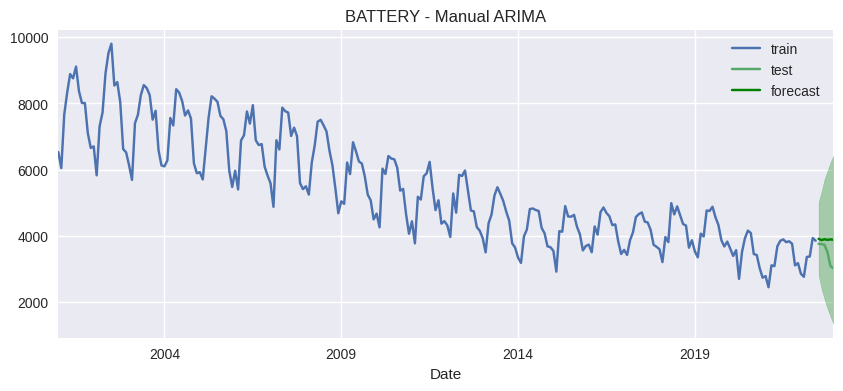

In [127]:
plot_forecast(battery_train["count"], battery_test["count"], battery_forecast_df,
              title="BATTERY - Manual ARIMA")

regression_metrics_ts(
    battery_test["count"],
    battery_forecast_df["mean"],
    label="BATTERY Manual ARIMA"
)

In [128]:
battery_auto = auto_arima(
    battery_train["count"],
    seasonal=True,
    m=12,
    trace=True
)

battery_auto_pred = battery_auto.predict(n_periods=6)

battery_auto_df = pd.DataFrame({
    "mean": battery_auto_pred
}, index=battery_test.index)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=2.94 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3999.181, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3753.329, Time=0.62 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3872.017, Time=0.59 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3997.267, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=4000.706, Time=0.06 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=inf, Time=2.05 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=3680.737, Time=1.27 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=3870.170, Time=0.43 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=3688.922, Time=3.40 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=3682.671, Time=6.22 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=3836.662, Time=1.35 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=3.96 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=3704.855, Time=1.08 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept

/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py:524: ModelFitWarning: Error fitting  ARIMA(2,1,1)(1,0,1)[12]           (if you do not want to see these warnings, run with error_action="ignore").
Traceback:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py", line 508, in _fit_candidate_model
    fit.fit(y, X=X, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 610, in fit
    self._fit(y, X, **fit_args)
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 531, in _fit
    fit, self.arima_res_ = _fit_wrapper()
                           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 517, in _fit_wrapper
    fitted = arima.fit(
             ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py", line 705, in fit
    mlefit = super().fit(start_p

 ARIMA(2,1,1)(1,0,1)[12]             : AIC=inf, Time=nan sec
 ARIMA(1,1,1)(1,0,1)[12]             : AIC=inf, Time=1.09 sec
 ARIMA(3,1,1)(1,0,1)[12]             : AIC=inf, Time=2.35 sec

Best model:  ARIMA(2,1,0)(1,0,1)[12]          
Total fit time: 84.776 seconds


------------------------------------------------------------
Regression Metrics: BATTERY Auto ARIMA
------------------------------------------------------------
MAE = 95.192
MSE = 17440.190
RMSE = 132.061
R2 = 0.820
MAPE = 2.61%


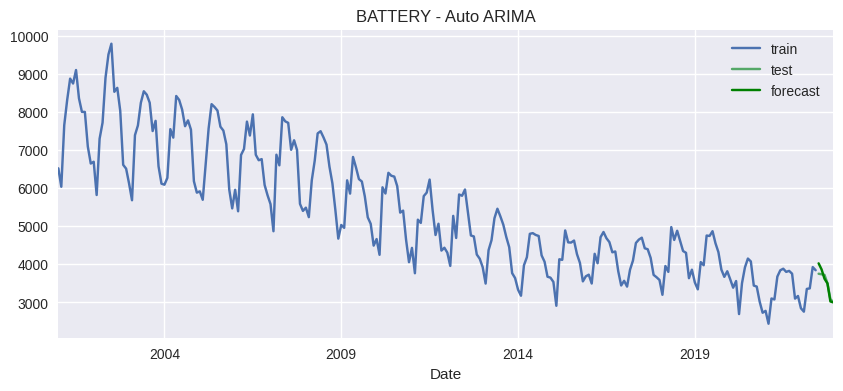

In [129]:
plot_forecast(battery_train["count"], battery_test["count"], battery_auto_df,
              title="BATTERY - Auto ARIMA")

regression_metrics_ts(
    battery_test["count"],
    battery_auto_df["mean"],
    label="BATTERY Auto ARIMA"
)

### Model Selection Criteria

We compare:
- MAE (lower is better)
- RMSE (lower is better)
- MAPE (percentage error)
- Residual smoothness (visual fit)

Final model is selected based on:
- lowest RMSE
- best alignment with test data trend

In [130]:
future_steps = 6

theft_final_model = theft_auto
battery_final_model = battery_auto

theft_future = theft_final_model.predict(n_periods=future_steps)
battery_future = battery_final_model.predict(n_periods=future_steps)

In [131]:
future_index = pd.date_range(
    start=df.index.max(),
    periods=future_steps+1,
    freq="MS"
)[1:]

theft_future = pd.Series(theft_future, index=future_index)
battery_future = pd.Series(battery_future, index=future_index)

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:975: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


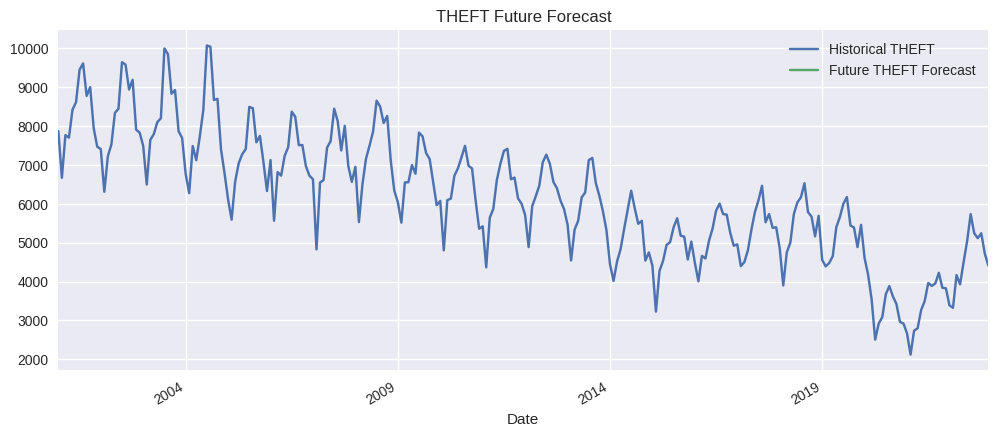

In [132]:
plt.figure(figsize=(12,5))
theft_ts["count"].plot(label="Historical THEFT")
theft_future.plot(label="Future THEFT Forecast")
plt.legend()
plt.title("THEFT Future Forecast")
plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:975: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


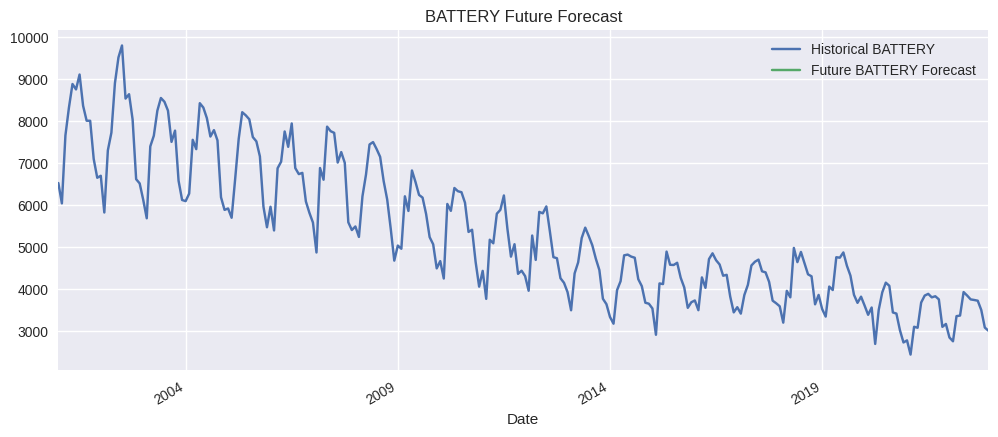

In [133]:
plt.figure(figsize=(12,5))
battery_ts["count"].plot(label="Historical BATTERY")
battery_future.plot(label="Future BATTERY Forecast")
plt.legend()
plt.title("BATTERY Future Forecast")
plt.show()

In [134]:
def compute_change(series):
    start = series.iloc[0]
    end = series.iloc[-1]

    net_change = end - start
    percent_change = (net_change / start) * 100

    return net_change, percent_change

In [135]:
theft_net, theft_pct = compute_change(theft_future)

print("THEFT Net Change:", theft_net)
print("THEFT Percent Change:", theft_pct)

THEFT Net Change: nan
THEFT Percent Change: nan


In [136]:
battery_net, battery_pct = compute_change(battery_future)

print("BATTERY Net Change:", battery_net)
print("BATTERY Percent Change:", battery_pct)

BATTERY Net Change: nan
BATTERY Percent Change: nan


### Final Comparison

We compare:
- Final month forecast
- Net change
- Percent change

#### Answers:
- Highest final crime level
- Highest increase
- Highest growth rate

### Recommendation

Based on forecasting results:

- If THEFT shows stronger growth → prioritize property crime prevention
- If BATTERY shows higher increase → focus on violent crime intervention
- Resource allocation should follow the faster-growing category

### Supporting Visualization

Use final forecast plots above as evidence for resource planning over next 6 months.